In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(
    r"C:\Users\Lenovo\Desktop\ML projects\ML-final_project(Industrial-Machine-Failure-Prediction)\archive\predictive_maintenance.csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 10


In [6]:
for column in df.columns:
    print(column)
    

UDI
Product ID
Type
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
Target
Failure Type


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [8]:
print(df.isnull().sum())


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [10]:
print(df["Target"].value_counts())
print()
print(df["Target"].value_counts(normalize=True) * 100)


Target
0    9661
1     339
Name: count, dtype: int64

Target
0    96.61
1     3.39
Name: proportion, dtype: float64


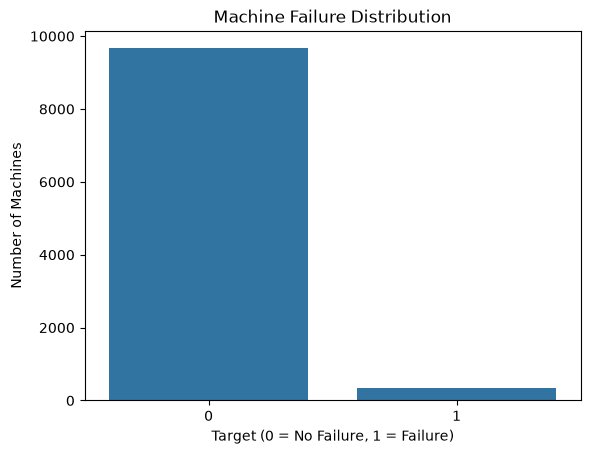

In [11]:
sns.countplot(x="Target", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Target (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Machines")

plt.show()


In [12]:
print(df["Failure Type"].value_counts())


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


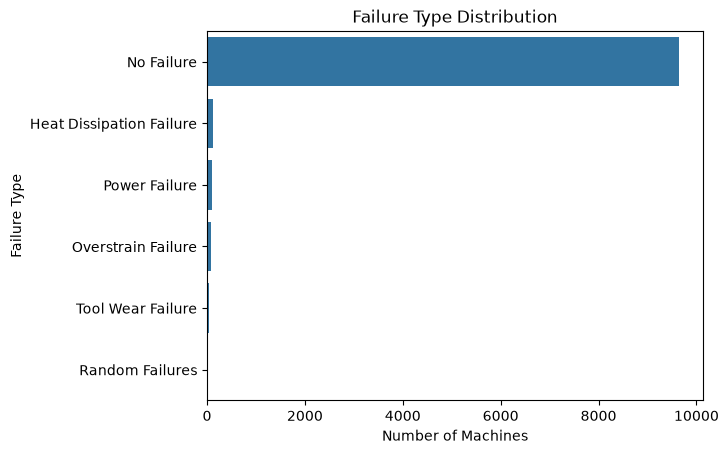

In [13]:
sns.countplot(
    y="Failure Type",
    data=df,
    order=df["Failure Type"].value_counts().index
)

plt.title("Failure Type Distribution")
plt.xlabel("Number of Machines")
plt.ylabel("Failure Type")

plt.show()

In [14]:
print(df["Type"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


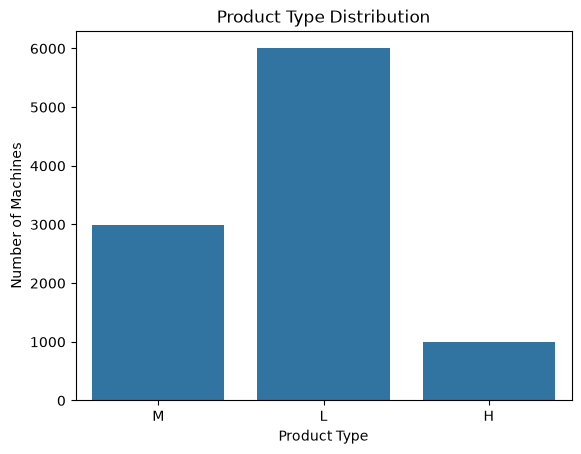

In [15]:
sns.countplot(x="Type", data=df)

plt.title("Product Type Distribution")
plt.xlabel("Product Type")
plt.ylabel("Number of Machines")

plt.show()

In [16]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_columns].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


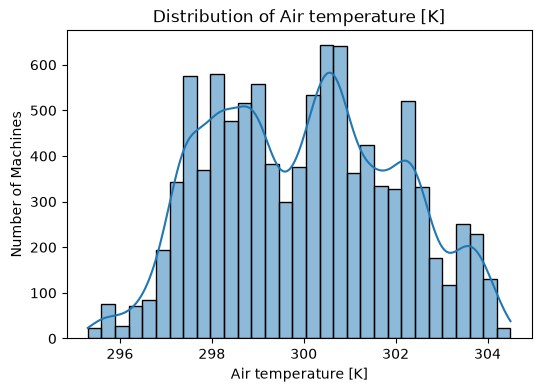

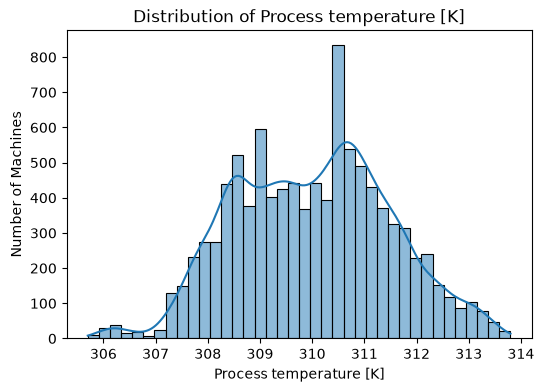

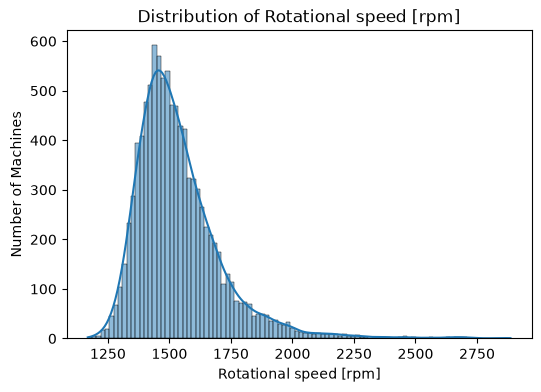

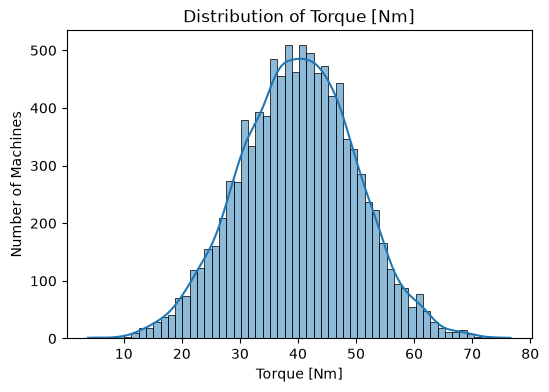

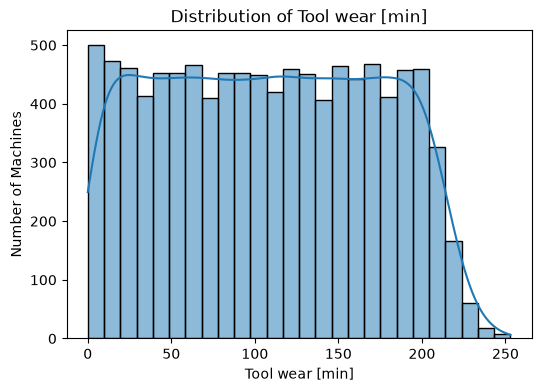

In [17]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[column], kde=True)
    
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Number of Machines")
    
    plt.show()

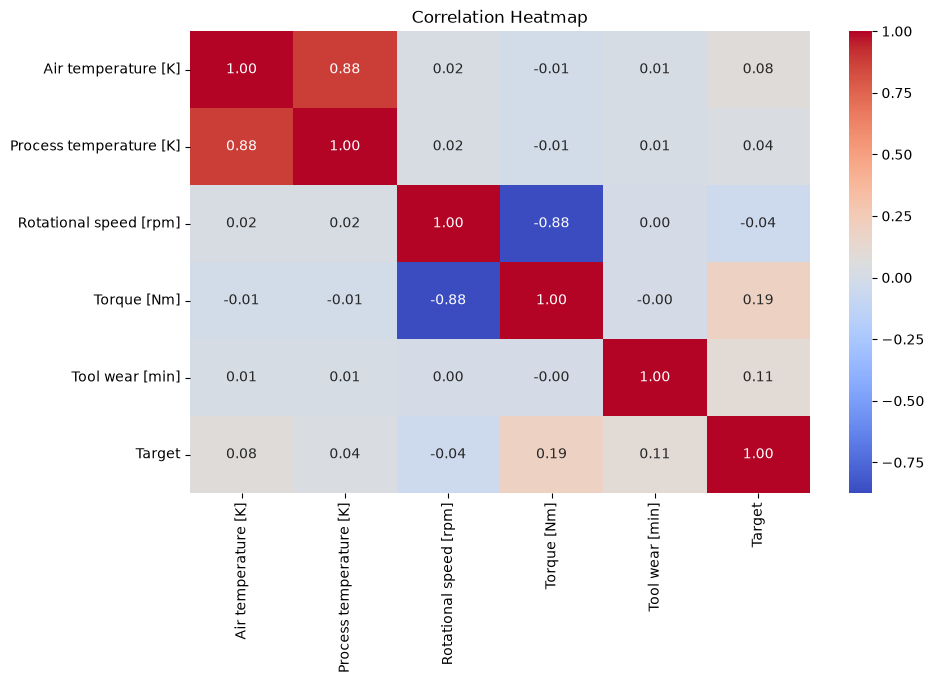

In [18]:
correlation_data = df[numeric_columns + ["Target"]]

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


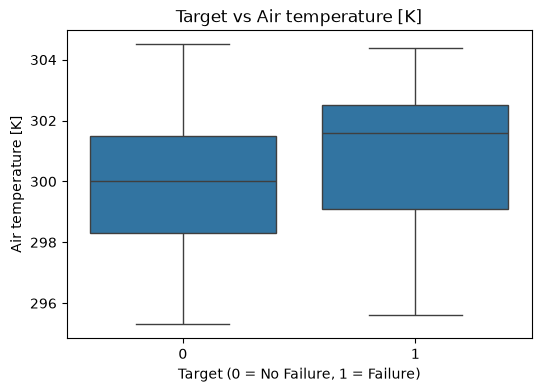

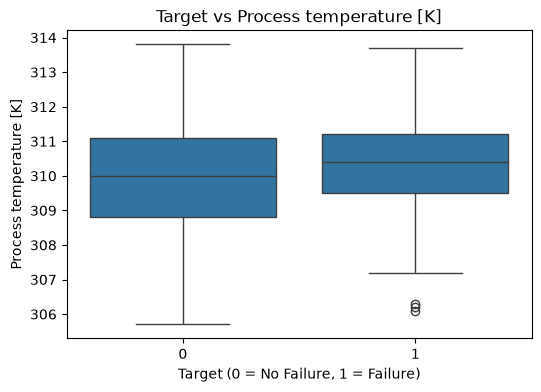

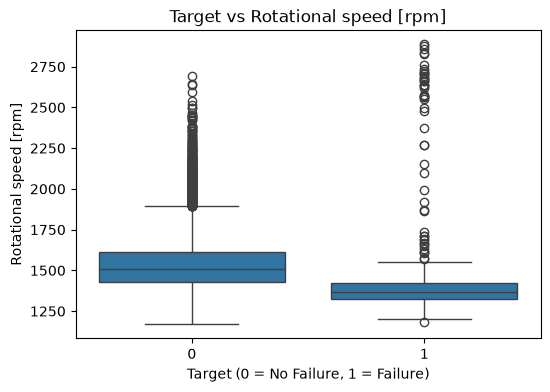

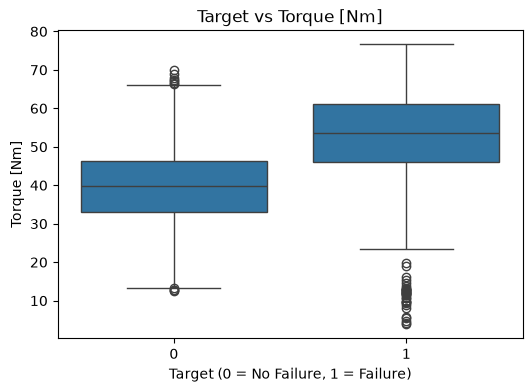

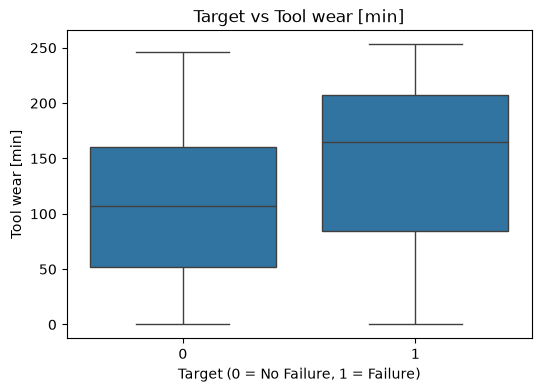

In [19]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(x="Target", y=column, data=df)
    
    plt.title("Target vs " + column)
    plt.xlabel("Target (0 = No Failure, 1 = Failure)")
    plt.ylabel(column)
    
    plt.show()

In [20]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features]
y = df["Target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Target


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (8000, 6)
Testing data: (2000, 6)

Training target distribution:
Target
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Target
0    1932
1      68
Name: count, dtype: int64


In [22]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [24]:
logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

y_probability_logistic = logistic_model.predict_proba(X_test)[:, 1]
roc_auc_logistic = roc_auc_score(y_test, y_probability_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))
print("ROC-AUC  :", round(roc_auc_logistic, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.8245
Precision: 0.1418
Recall   : 0.8235
F1 Score : 0.2419
ROC-AUC  : 0.907


Confusion Matrix:
[[1593  339]
 [  12   56]]


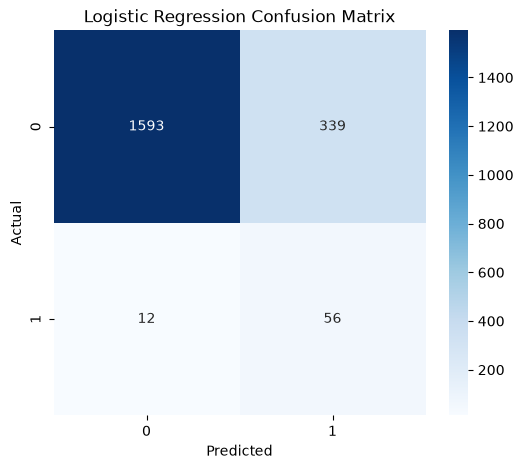

In [26]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [27]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [28]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

y_probability_tree = decision_tree_model.predict_proba(X_test)[:, 1]
roc_auc_tree = roc_auc_score(y_test, y_probability_tree)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Results
--------------------
Accuracy : 0.9365
Precision: 0.3314
Recall   : 0.8529
F1 Score : 0.4774
ROC-AUC  : 0.8761


Confusion Matrix:
[[1815  117]
 [  10   58]]


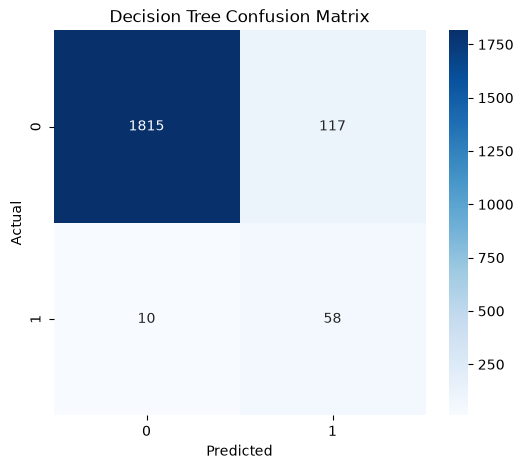

In [29]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Confusion Matrix:")
print(cm_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [31]:
accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest)
recall_forest = recall_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest)

y_probability_forest = random_forest_model.predict_proba(X_test)[:, 1]
roc_auc_forest = roc_auc_score(y_test, y_probability_forest)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(accuracy_forest, 4))
print("Precision:", round(precision_forest, 4))
print("Recall   :", round(recall_forest, 4))
print("F1 Score :", round(f1_forest, 4))
print("ROC-AUC  :", round(roc_auc_forest, 4))


Random Forest Results
--------------------
Accuracy : 0.9535
Precision: 0.4101
Recall   : 0.8382
F1 Score : 0.5507
ROC-AUC  : 0.9644


In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_forest
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_forest
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_forest
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_forest
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree,
        roc_auc_forest
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9070
1,Decision Tree,0.9365,0.3314,0.8529,0.4774,0.8761
2,Random Forest,0.9535,0.4101,0.8382,0.5507,0.9644


In [33]:
best_model = random_forest_model

print("Selected model: Random Forest")
print("Reason: Highest F1 Score and ROC-AUC among the tested models.")

Selected model: Random Forest
Reason: Highest F1 Score and ROC-AUC among the tested models.


In [34]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/machine_failure_model.pkl"
)

print("Model saved successfully!")
print("Location: ../models/machine_failure_model.pkl")

Model saved successfully!
Location: ../models/machine_failure_model.pkl


In [35]:
new_machine = pd.DataFrame({
    "Type": ["M"],
    "Air temperature [K]": [300.0],
    "Process temperature [K]": [310.0],
    "Rotational speed [rpm]": [1500],
    "Torque [Nm]": [50],
    "Tool wear [min]": [100]
})

prediction = best_model.predict(new_machine)
probability = best_model.predict_proba(new_machine)[0][1]

print("Prediction:", prediction[0])
print("Failure Probability:", round(probability * 100, 2), "%")

Prediction: 0
Failure Probability: 5.16 %


In [36]:
if prediction[0] == 1:
    print("⚠️ Machine Failure Risk Detected")
else:
    print("✅ Machine is predicted as Normal")

print("Estimated Failure Probability:", round(probability * 100, 2), "%")

✅ Machine is predicted as Normal
Estimated Failure Probability: 5.16 %


In [37]:
import joblib
import os

os.makedirs("../Model", exist_ok=True)

model_path = "../Model/machine_failure_model.pkl"

joblib.dump(best_model, model_path)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: ../Model/machine_failure_model.pkl


In [38]:
import os

print("Notebook working directory:")
print(os.getcwd())

Notebook working directory:
C:\Users\Lenovo\Desktop\ML projects\ML-final_project(Industrial-Machine-Failure-Prediction)


In [39]:
import joblib
import os

model_path = "Model/machine_failure_model.pkl"

joblib.dump(best_model, model_path)

print("Model saved successfully!")
print("Saved at:", os.path.abspath(model_path))

Model saved successfully!
Saved at: C:\Users\Lenovo\Desktop\ML projects\ML-final_project(Industrial-Machine-Failure-Prediction)\Model\machine_failure_model.pkl
